# v1 baseline, re-run on the corrected pipeline

v1 is the pre-nitro-zone design: location and count, two XGBoost action models,
and a player metric that averages the value of whichever action the hitter
actually took.

It is the simplest design worth measuring, so it sets the floor: any later
variant has to justify its extra complexity against these numbers. It is built
here on the same pipeline, learner, hyperparameters and folds as everything
else, so differences further down the scorecard are attributable to design
rather than to data handling.

Design and results recorded in `FINDINGS.md`.

In [1]:
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as D
from src import evaluate as E
from src.baselines import V1_FEATURES, V1_TAKE_PARAMS, V1_SWING_PARAMS

pd.set_option('display.width', 130)
sns.set_theme(style='whitegrid')
PALETTE = ['#FFB000', '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#3D1EB2']

SEASONS = range(2021, 2026)          # 2026 is kept out of model selection; not loaded here
FOLDS = E.GENERIC_FOLDS
print('features:', V1_FEATURES)
print(f'take : {V1_TAKE_PARAMS}')
print(f'swing: {V1_SWING_PARAMS}')

features: ['plate_x_mid', 'plate_z_mid', 'count']
take : {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'random_state': 1126, 'tree_method': 'hist', 'max_depth': 8, 'learning_rate': 0.03}
swing: {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'random_state': 1126, 'tree_method': 'hist', 'max_depth': 7, 'learning_rate': 0.01}


## Data

Harmonized location and the pitcher-batting filter. `plate_x_mid`/`plate_z_mid`
are the harmonized coordinates — harmonization is a data correction, so it
applies. Batter-frame mirroring and zone normalization are *design* changes
belonging to v3 and are not features here; `add_zone_frame` is called only so
the evaluation can bin pitches by location.

2026 is not loaded: it is kept out of model selection. It is not a clean test —
earlier versions of the project scored it — so it will be reported at the end as
an out-of-regime evaluation.

In [2]:
df = D.drop_pitchers_batting(D.load_seasons(SEASONS, verbose=True))
df = D.add_zone_frame(df.dropna(subset=['plate_x_mid', 'plate_z_mid']))
print(f'\nanalysis frame: {len(df):,} rows')

3,563,787 rows in
  -   11,687  non-decision (auto ball/strike)
  -    1,692  no tracked location
  -       44  no trajectory
  -       23  no delta_run_exp
  -       44  in-play with unmapped event
 3,550,297  kept



analysis frame: 3,517,807 rows


## Fit and score, on rolling-origin folds

Each season from 2023 to 2025 is scored by a model that never saw it:

| fold | train | held out |
|---|---|---|
| 1 | 2021–22 | 2023 |
| 2 | 2021–23 | 2024 |
| 3 | 2021–24 | 2025 |

Everything learned is learned per fold from the training seasons only — the
(outcome, count) run-value table that defines the target, both action models,
and the count-only reference predictor. Every check below uses the held-out
seasons alone.

In [3]:
run = E.run_folds(df, V1_FEATURES, FOLDS, in_sample=True)
run.held.groupby('fold').agg(pitches=('target', 'size'), swings=('swing', 'sum'))

,pitches,swings
fold,,
2023,713632,339208
2024,703828,337782
2025,705409,336956


## Sub-model performance

Always against a count-only predictor fitted on the same training seasons,
never on its own. The target is the mean run value of an (outcome, count) pair,
so a model given only the count already reproduces much of it; the gap above
that floor is what location buys.

Pitch-level RMSE first.

In [4]:
E.rmse_vs_count_baseline(run.held).round(4)

,n,rmse,rmse_count_only,improvement_%
action,,,,
take,1108923,0.0442,0.0772,42.7792
swing,1013946,0.2988,0.3012,0.7960


Location and count buy 43% over a count-only lookup for takes, and 0.8% for
swings.

For the take model that gap is informative. For the swing model pitch-level
RMSE is the wrong instrument. An individual swing outcome is close to
irreducible — the same pitch in the same count can be a home run or a
groundout — so the error is dominated by noise that nothing observable before
the pitch can predict. The model is not trying to predict that; it estimates a
conditional mean, the average run value of swinging at this location in this
count. So score it on that.

Below, held-out pitches are binned by batter-frame location × count (12 × 12
locations, bins with at least 200 pitches). In each bin the observed mean target
is compared with the mean prediction and with the count-only predictor.
`noise` is the error a perfect predictor would still show, because each
observed bin mean is itself an estimate; `signal_recovered` is the share of
the between-bin structure the count-only predictor misses that the model
captures; `slope` regresses observed bin means on predicted ones, where 1 is
calibrated.

In [5]:
cal = {a: E.bin_calibration(run.held, a) for a in ('take', 'swing')}
pd.concat(cal, names=['action']).round(4)

bins  pitches     err  err_count_only   noise  signal_recovered   slope
action season                                                                         
take   2023     262   122644  0.0027          0.0377  0.0013            0.9961  1.0240
       2024     255   118335  0.0033          0.0374  0.0013            0.9933  1.0146
       2025     260   121936  0.0045          0.0371  0.0013            0.9865  1.0418
swing  2023     603   232478  0.0214          0.0378  0.0162            0.8314  1.3260
       2024     595   231511  0.0205          0.0354  0.0158            0.8322  1.2493
       2025     596   232635  0.0199          0.0345  0.0160            0.8490  1.2064

**The swing model does learn location — pitch-level RMSE hid it.** On bin
means it cuts the count-only error from 0.0359 to 0.0206 runs, against a noise
floor of about 0.016, recovering **83–85%** of the between-bin structure the
count-only predictor misses. That share is tied to this binning, so it is for
comparing variants, not a ceiling.

**It appears to understate the location contrast.** The calibration slope is
1.21–1.33: across bins, observed means spread more than the predictions do, so
good swing locations look not quite good enough and bad ones not quite bad
enough. Two limits on that reading: the check groups by location and count, so
it says nothing about anything that varies within a bin; and each bin mean
carries ~0.016 runs of sampling noise, so the slope needs a confidence interval
before it is more than "consistently above 1". A possible cause is v1's swing
hyperparameters (learning rate 0.01 over 200 rounds), held fixed across every
variant.

**The take model is close to exact**: 99% of the between-bin structure, slope
1.01–1.04. What follows a take is an umpire's call, and location nearly
determines it.

## Player metric and reliability

v1's player metric is the mean value of the action taken (`y_pred`), z-scored
within season to 100 ± 10, for hitters with at least 500 pitches.

In [6]:
res = E.harness(run, 'v1', value_col='y_pred')
scores = res['scores']
print('qualified hitters (>=500 pitches) per held-out season:')
print(scores.groupby('season').size().to_string())
res['yoy'].round(3)

qualified hitters (>=500 pitches) per held-out season:
season
2023    432
2024    425
2025    419


,hitters,r,r2
pair,,,
2023->2024,332,0.741,0.549
2024->2025,326,0.710,0.504


In [7]:
res['split_half'].round(3)

,hitters,r_half,r_spearman_brown
season,,,
2023,421,0.654,0.791
2024,417,0.564,0.721
2025,405,0.616,0.762


## Validity

Three questions reliability cannot answer: does the metric track the two
halves of a swing decision, is it measuring the pitches a hitter was thrown
rather than his decisions, and does it predict anything.

Construct validity is reported as partial correlations — chase rate holding
zone-swing rate fixed, and the reverse — because the two correlate through
overall aggression and a raw correlation against either is confounded.

In [8]:
res['construct'].round(3)

,hitters,chase (raw),zone_swing (raw),chase | zone_swing,zone_swing | chase,"corr(chase, zone_swing)"
0,1276,-0.774,-0.023,-0.884,0.673,0.505


In [9]:
res['zone_pct'].round(3)

,hitters,r,variance_explained_%,zone_pct_std
season,,,,
2023,432,0.091,0.820,0.021
2024,425,0.099,0.974,0.021
2025,419,0.058,0.334,0.022


In [10]:
res['predictive'].round(3)

,hitters,r_raw,r_partial
pair,,,
2023->2024,332,0.288,0.149
2024->2025,326,0.274,0.121


## Sanity checks

Reliability statistics cannot tell a well-behaved metric from a
consistently-wrong one: a metric measuring the wrong quantity can be perfectly
stable year to year. The leaderboard can. Hitters at the extremes of plate
discipline are known independently of any model, so if the ordering disagrees
with reputation — patient hitters low, free swingers high — something is wrong
no matter how good the reliability looks.

2025 is the latest held-out season.

In [11]:
try:
    from pybaseball import playerid_reverse_lookup
    s25 = scores[scores.season == 2025].copy()
    names = playerid_reverse_lookup(s25.batter.tolist())
    names['name'] = (names.name_first + ' ' + names.name_last).str.title()
    s25 = s25.merge(names[['key_mlbam', 'name']], left_on='batter', right_on='key_mlbam')
    cols = ['name', 'pitches', 'decision_value']
    print('TOP 10, 2025'); display(s25.nlargest(10, 'decision_value')[cols].round(1))
    print('BOTTOM 10, 2025'); display(s25.nsmallest(10, 'decision_value')[cols].round(1))
except Exception as exc:
    print(f'name lookup unavailable ({exc}); showing ids')
    display(scores[scores.season == 2025].nlargest(10, 'decision_value').round(1))

Gathering player lookup table. This may take a moment.


TOP 10, 2025


,name,pitches,decision_value
154,Kyle Tucker,2275,128.5
139,Ronald Acuña,1741,127.6
357,Dylan Beavers,615,127.6
31,Max Muncy,1603,126.5
280,Davis Schneider,1012,124.7
97,Matt Thaiss,768,123.8
142,Leo Rivas,520,123.8
116,Gleyber Torres,2652,123.5
180,Juan Soto,2968,122.4
20,George Springer,2305,121.9


BOTTOM 10, 2025


,name,pitches,decision_value
47,Javier Báez,1543,66.3
83,Edmundo Sosa,942,73.1
268,Lenyn Sosa,2056,73.5
296,Jhonkensy Noel,563,73.6
0,Martín Maldonado,569,75.3
257,Denzel Clarke,631,76.2
416,Hyeseong Kim,660,76.5
256,Michael Harris,2173,78.8
326,Angel Martínez,1797,78.9
354,Joey Ortiz,1873,79.7


Text(0.5, 0.98, 'v1 scored surface, 2025 held out — catcher frame')

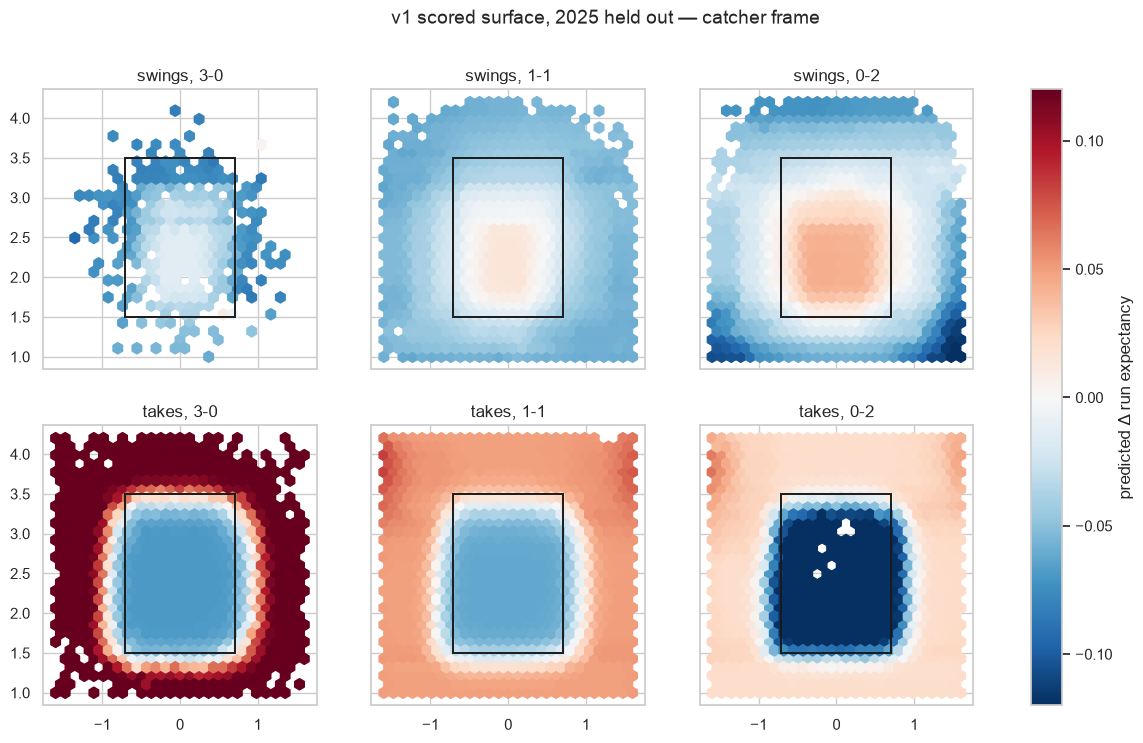

In [12]:
# The scored surface, by count, on the 2025 held-out season. 3-0 and 0-2 must
# look materially different, and the swing surface must be positive over the
# plate and negative well outside.
h = run.held[run.held.season == 2025]
fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for row, (swung, lbl) in enumerate([(True, 'swings'), (False, 'takes')]):
    for col, cnt in enumerate(['3-0', '1-1', '0-2']):
        g = h[(h.swing == swung) & (h['count'].astype(str) == cnt)]
        hb = ax[row, col].hexbin(g.plate_x_mid, g.plate_z_mid, C=g.y_pred, gridsize=26,
                                 extent=[-1.6, 1.6, 1.0, 4.2], cmap='RdBu_r', vmin=-0.12, vmax=0.12)
        ax[row, col].add_patch(plt.Rectangle((-0.708, 1.5), 1.416, 2.0, fill=False, color='k', lw=1.4))
        ax[row, col].set_title(f'{lbl}, {cnt}')
fig.colorbar(hb, ax=ax, label='predicted Δ run expectancy')
fig.suptitle('v1 scored surface, 2025 held out — catcher frame', y=0.98, fontsize=14)

## Findings

All figures are held out: each season scored by a model that never saw it.

**Reliable.** Split-half reliability is 0.72–0.79 and year-over-year R² 0.50
(2024→25) to 0.55 (2023→24). The metric measures something stable about a
hitter.

**Tracks both halves of the decision.** Holding the other fixed, the metric
falls with chase rate (partial r −0.884) and rises with zone-swing rate
(+0.673).

**Little pitch-mix contamination.** Zone% explains 0.3–1.0% of the metric's
variance, against the ~23% that retired SOTO. Scoring the action taken means a
taken ball and a swung-at strike both pay, and the two roughly cancel — though
conceptually the design still credits a hitter for the pitches he was thrown.

**Weakly predictive.** Controlling for current production, decision value
predicts next-season production at a partial r of 0.149 (2023→24) and 0.121
(2024→25).

**Little optimism in-sample.** Scoring the last fold's own training seasons
moves the player-metric checks by at most 0.03 (last cell; the in-sample pairs
are earlier seasons). A location-and-count model has little room to overfit.

**Face validity holds.** The 2025 leaderboard puts Tucker, Acuña, Muncy and
Soto near the top and Báez at the bottom.

**Where the weakness sits.** Not where pitch-level RMSE pointed. The swing
model recovers most of the location structure in swing value, though the
location check suggests it understates the gap between good and bad swing
locations (slope above 1 in every season, no interval yet).

In [13]:
# Held-out scorecard row, with the last fold's model scored on its own training
# seasons beside it. The in-sample row shows the optimism; it is never averaged
# into the held-out figures.
ins = E.in_sample_checks(run, 'v1', value_col='y_pred')
pd.DataFrame([res['summary'], ins['summary']]).set_index('variant').T

variant,v1,v1 (in-sample)
chase | zone_swing,-0.884,-0.885
zone_swing | chase,0.673,0.657
split-half r,0.758,0.757
YoY R2 (mean),0.526,0.553
Zone% |r|,0.082,0.105
next-season r (partial),0.135,0.135
swing bin err / count-only,0.0206 / 0.0359,NaN
swing signal recovered,0.838,NaN
swing calib slope,1.261,NaN
take bin err / count-only,0.0035 / 0.0374,NaN
